
# 08 · Tree models and the integrated model

Gradient-boosted trees and random forests on the tabular feature table, evaluated on the same folds
as the neural networks so the results are directly comparable.

Four feature sets are compared, which isolates what each source of information contributes:

| set | features |
|---|---|
| environment | sea temperature, wind speed and direction, season, time of day |
| acoustic | the acoustic summaries measured from each recording |
| environment + acoustic | both of the above |
| acoustic + GRU | the acoustic summaries plus `shannon_pred_gru` |
| environment + GRU | environment plus `shannon_pred_gru` |
| environment + acoustic + GRU | all of the above |

Each of the three sets containing `shannon_pred_gru` has a counterpart without it, so the effect of
adding the GRU prediction can be measured against three different backgrounds: the acoustic
summaries alone, the environmental context alone, and both together. All three comparisons are
paired by seed and share the same folds, so the only thing that differs between a pair is the
presence of that one column.

### Design

Targets are properties of a whole recording, so the clip-level table is aggregated to one row per
recording before modelling. Modelling on clip rows would place clips from the same recording in both
training and test, and would inflate the sample size from 72 to 2,670.

Species counts and total abundance are excluded. Both are the quantities the target is computed
from, so including them would leak the answer.

Fold assignments are read from `runs/folds_k5_seed*.json`, written by notebook 04 or 05. Every
configuration is repeated over five seeds. `shannon_pred_gru` is out-of-fold, so it carries no
information about the recording it describes.

### Before running

Notebooks 03, 07 and either 04 or 05 must have run, producing `merged_features_with_pred.csv` and
the fold files.

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib

In [ ]:

import os, json, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

BASE      = f"/scratch/{os.environ.get('USER','username')}/capstone"
PRED_CSV  = os.path.join(BASE, "merged_features_with_pred.csv")
RUNS      = os.path.join(BASE, "runs")
FIG_DIR   = os.path.join(BASE, "figures", "trees"); os.makedirs(FIG_DIR, exist_ok=True)

TARGET   = "shannon_rare_no_anchoa"
PRED_COL = "shannon_pred_gru"
K_FOLDS  = 5
SEEDS    = [0, 1, 2, 3, 4]

ENV_NUMERIC     = ["SST_c", "WSPD_mps", "WDIR_deg"]
ENV_CATEGORICAL = ["Season", "Time_of_day"]

ACOUSTIC = [
    # amplitude and envelope
    "RMS", "Floor", "Dynamics",
    # transients and events
    "Click_Count", "Click_Frequency",
    "Event_Count", "Mean_Duration", "Max_Duration",
    # spectral shape
    "centroid", "bandwidth", "rolloff",
    # soundscape indices
    "aci", "ADI", "entropy",
    # band energy fractions
    "band_100_500", "band_500_1000", "band_1000_2000",
    # power spectrum, 100 Hz bins across 100-2000 Hz
    "pwr_0100_0200", "pwr_0200_0300", "pwr_0300_0400", "pwr_0400_0500",
    "pwr_0500_0600", "pwr_0600_0700", "pwr_0700_0800", "pwr_0800_0900",
    "pwr_0900_1000", "pwr_1000_1100", "pwr_1100_1200", "pwr_1200_1300",
    "pwr_1300_1400", "pwr_1400_1500", "pwr_1500_1600", "pwr_1600_1700",
    "pwr_1700_1800", "pwr_1800_1900", "pwr_1900_2000",
    # measured on the unfiltered signal
    "zcr_fullband",
]

print("project root:", os.path.basename(BASE.rstrip("/")) + "/")
print(f"target {TARGET} | {len(SEEDS)} seeds x {K_FOLDS} folds")

project root: capstone/
target shannon_rare_no_anchoa | 5 seeds x 5 folds



## Aggregate to recording level

Acoustic features are averaged across each recording's clips. Environmental readings and the target
are already constant within a recording.

In [ ]:

if not os.path.exists(PRED_CSV):
    raise SystemExit("merged_features_with_pred.csv not found. Run 07_gru_predictions.ipynb first.")
D = pd.read_csv(PRED_CSV)

missing = [c for c in ACOUSTIC + ENV_NUMERIC + ENV_CATEGORICAL + [TARGET, PRED_COL]
           if c not in D.columns]
if missing:
    raise SystemExit(f"columns listed above are absent from the feature table: {missing}")

SPECIES = list(D.columns[list(D.columns).index("Lagodon rhomboides"):
                         list(D.columns).index("Hemirhamphus meeki") + 1])
EXCLUDED = set(SPECIES) | {"total_abundance_no_anchoa", "richness_rare_no_anchoa"}
IDS = {"Filename", "recording_key", "date", "collection", "window_start_sec"}

accounted = set(ACOUSTIC) | set(ENV_NUMERIC) | set(ENV_CATEGORICAL) | EXCLUDED | IDS | \
            {TARGET, PRED_COL}
unaccounted = [c for c in D.columns
               if c not in accounted and pd.api.types.is_numeric_dtype(D[c])]
if unaccounted:
    print(f"NOTE: {len(unaccounted)} column(s) present but not used: {unaccounted}")

agg = {c: "mean" for c in ACOUSTIC}
agg.update({c: "first" for c in ENV_NUMERIC + ENV_CATEGORICAL + [TARGET, PRED_COL]})
R = D.groupby("recording_key").agg(agg).reset_index()

constant = [c for c in ACOUSTIC + ENV_NUMERIC if R[c].nunique(dropna=False) <= 1]
if constant:
    print(f"dropping {len(constant)} constant column(s): {constant}")

R = pd.get_dummies(R, columns=ENV_CATEGORICAL, drop_first=True)
DUMMIES = [c for c in R.columns
           if any(c.startswith(p + "_") for p in ENV_CATEGORICAL)]

ENVCOLS  = [c for c in ENV_NUMERIC if c not in constant] + DUMMIES
ACOUSTIC = [c for c in ACOUSTIC if c not in constant]

print(f"{len(R)} recordings | {len(ENVCOLS)} environmental, {len(ACOUSTIC)} acoustic features")
print(f"  categorical expanded to: {DUMMIES}")
print(f"target: {R[TARGET].min():.3f}-{R[TARGET].max():.3f}, sd {R[TARGET].std():.3f}")

FEATURE_SETS = {
    "environment":                  ENVCOLS,
    "acoustic":                     ACOUSTIC,
    "environment + acoustic":       ENVCOLS + ACOUSTIC,
    "acoustic + GRU":               ACOUSTIC + [PRED_COL],
    "environment + GRU":            ENVCOLS + [PRED_COL],
    "environment + acoustic + GRU": ENVCOLS + ACOUSTIC + [PRED_COL],
}
for k, v in FEATURE_SETS.items():
    print(f"  {k:30s} {len(v):3d} features")

72 recordings | 7 environmental, 37 acoustic features
  categorical expanded to: ['Season_Spring', 'Season_Summer', 'Season_Winter', 'Time_of_day_n']
target: 0.699-2.171, sd 0.374
  environment                      7 features
  acoustic                        37 features
  environment + acoustic          44 features
  acoustic + GRU                  38 features
  environment + GRU                8 features
  environment + acoustic + GRU    45 features



## Shared folds

The same assignments the neural networks used, so every model is scored on identical splits.

In [4]:

def load_folds(seed, k=K_FOLDS):
    p = os.path.join(RUNS, f"folds_k{k}_seed{seed}.json")
    if not os.path.exists(p):
        raise SystemExit(f"{os.path.basename(p)} not found in runs/. Run notebook 04 or 05 first.")
    d = json.load(open(p))["folds"]
    missing = [r for r in R["recording_key"] if r not in d]
    if missing:
        raise SystemExit(f"fold file does not cover: {missing[:3]}")
    return R["recording_key"].map(d).to_numpy()

fold_of = {s: load_folds(s) for s in SEEDS}
sizes = pd.Series(fold_of[SEEDS[0]]).value_counts().sort_index().tolist()
print(f"fold sizes (seed {SEEDS[0]}): {sizes}")

fold sizes (seed 0): [15, 15, 14, 14, 14]



## Cross-validation

Each fold trains on the other four and predicts the held-out recordings. Pooled R² over all 72
out-of-fold predictions is the headline metric, matching notebook 06. MAE and RMSE are also recorded
per fold.

In [5]:

def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(mae=float(np.abs(p - y).mean()),
                rmse=float(np.sqrt(np.mean((p - y) ** 2))),
                r2=(1 - float(np.sum((y - p) ** 2)) / ss_tot) if ss_tot > 0 else np.nan)

def build(model, seed):
    if model == "xgboost":
        return XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            random_state=seed, n_jobs=4, verbosity=0)
    return RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                 max_features="sqrt", random_state=seed, n_jobs=4)

def run_cv(model, cols, seed):
    """Out-of-fold predictions and per-fold metrics for one model, feature set and seed."""
    X = R[cols].to_numpy(dtype=float)
    y = R[TARGET].to_numpy(dtype=float)
    folds = fold_of[seed]
    oof = np.full(len(y), np.nan)
    per_fold, imps = [], []
    for f in range(K_FOLDS):
        te = folds == f
        m = build(model, seed).fit(X[~te], y[~te])
        oof[te] = m.predict(X[te])
        per_fold.append(metrics(y[te], oof[te]))
        imps.append(getattr(m, "feature_importances_", np.zeros(len(cols))))
    return oof, metrics(y, oof), per_fold, np.mean(imps, axis=0)

rows, folds_long, importance = [], [], {}
for model in ["xgboost", "random forest"]:
    for name, cols in FEATURE_SETS.items():
        for seed in SEEDS:
            oof, pooled, per_fold, imp = run_cv(model, cols, seed)
            rows.append(dict(model=model, features=name, seed=seed, n_features=len(cols),
                             **pooled))
            for i, m in enumerate(per_fold):
                folds_long.append(dict(model=model, features=name, seed=seed, fold=i, **m))
            importance.setdefault((model, name), []).append(pd.Series(imp, index=cols))
    print(f"{model} complete")

S  = pd.DataFrame(rows)
FL = pd.DataFrame(folds_long)

xgboost complete
random forest complete



## Results

Mean over seeds, with the seed-to-seed standard deviation. The baseline predicts the training mean.

In [6]:

base = float(np.abs(R[TARGET] - R[TARGET].mean()).mean())
g = (S.groupby(["model", "features"])
       .agg(n_features=("n_features", "first"),
            R2=("r2", "mean"), R2_sd=("r2", "std"),
            MAE=("mae", "mean"), MAE_sd=("mae", "std"),
            RMSE=("rmse", "mean"), RMSE_sd=("rmse", "std"))
       .reset_index())
order = list(FEATURE_SETS)
g["_o"] = g["features"].map({k: i for i, k in enumerate(order)})
g = g.sort_values(["model", "_o"]).drop(columns="_o")
with pd.option_context("display.float_format", lambda v: f"{v:.4f}", "display.width", 200):
    print(g.to_string(index=False))
print(f"\nmean-baseline MAE: {base:.4f}")

print("\nEffect of adding the GRU prediction, paired by seed:")
for a_set, b_set in [("acoustic", "acoustic + GRU"),
                     ("environment", "environment + GRU"),
                     ("environment + acoustic", "environment + acoustic + GRU")]:
    print(f"  {b_set} vs {a_set}")
    for model in ["xgboost", "random forest"]:
        a = S[(S.model == model) & (S.features == a_set)].set_index("seed")["r2"]
        b = S[(S.model == model) & (S.features == b_set)].set_index("seed")["r2"]
        d = b - a
        print(f"    {model:14s} ΔR² = {d.mean():+.4f} ± {d.std():.4f}  "
              f"(improves in {int((d > 0).sum())}/{len(d)} seeds)")

        model                     features  n_features     R2  R2_sd    MAE  MAE_sd   RMSE  RMSE_sd
random forest                  environment           7 0.2948 0.0295 0.2459  0.0059 0.3121   0.0065
random forest                     acoustic          37 0.1475 0.0433 0.2758  0.0075 0.3431   0.0087
random forest       environment + acoustic          44 0.1810 0.0356 0.2685  0.0078 0.3363   0.0073
random forest               acoustic + GRU          38 0.1669 0.0505 0.2727  0.0086 0.3392   0.0103
random forest            environment + GRU           8 0.3293 0.0323 0.2360  0.0068 0.3044   0.0073
random forest environment + acoustic + GRU          45 0.2028 0.0475 0.2642  0.0081 0.3318   0.0099
      xgboost                  environment           7 0.1828 0.0331 0.2649  0.0048 0.3360   0.0069
      xgboost                     acoustic          37 0.0345 0.0894 0.2990  0.0129 0.3649   0.0169
      xgboost       environment + acoustic          44 0.0820 0.0753 0.2911  0.0135 0.3559   0.0145



Per-fold MAE across all seeds, five folds each. The dashed line is the mean baseline.

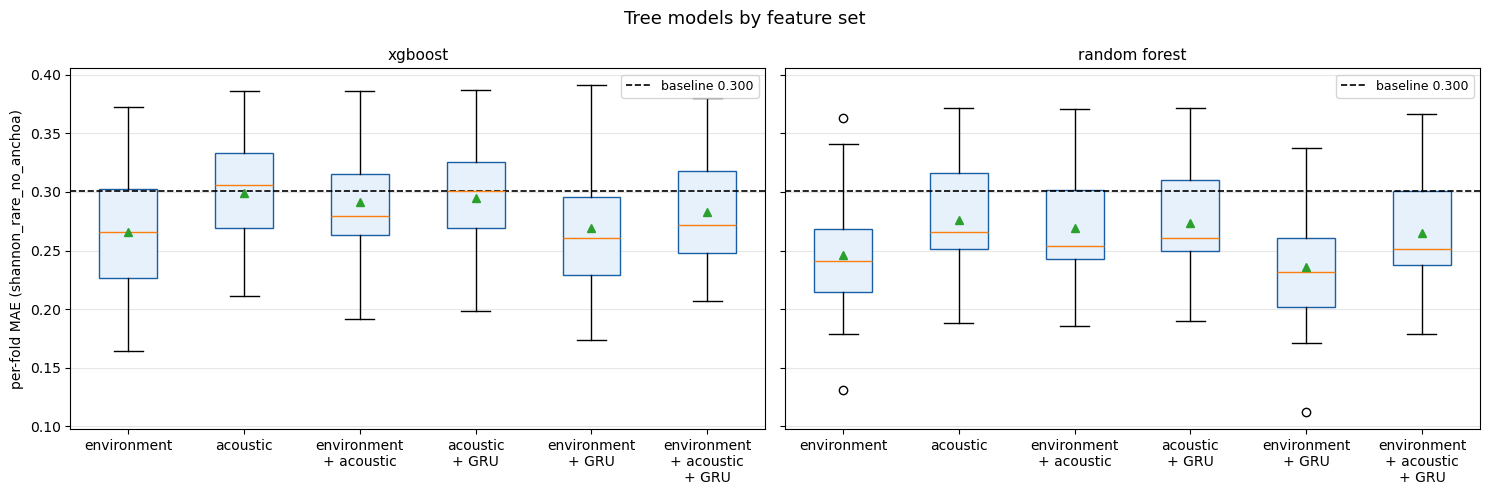

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0), sharey=True)
for ax, model in zip(axes, ["xgboost", "random forest"]):
    data = [FL[(FL.model == model) & (FL.features == k)]["mae"].values for k in order]
    bp = ax.boxplot(data, showmeans=True, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#E6F1FB"); patch.set_edgecolor("#185FA5")
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([k.replace(" + ", "\n+ ") for k in order], fontsize=10)
    ax.axhline(base, color="k", ls="--", lw=1.2, label=f"baseline {base:.3f}")
    ax.set_title(model, fontsize=11); ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=9)
axes[0].set_ylabel(f"per-fold MAE ({TARGET})")
fig.suptitle("Tree models by feature set", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "boxplot_feature_sets.png"), dpi=150, bbox_inches="tight")
plt.show()


The fifteen features each model relies on most, using the full feature set.

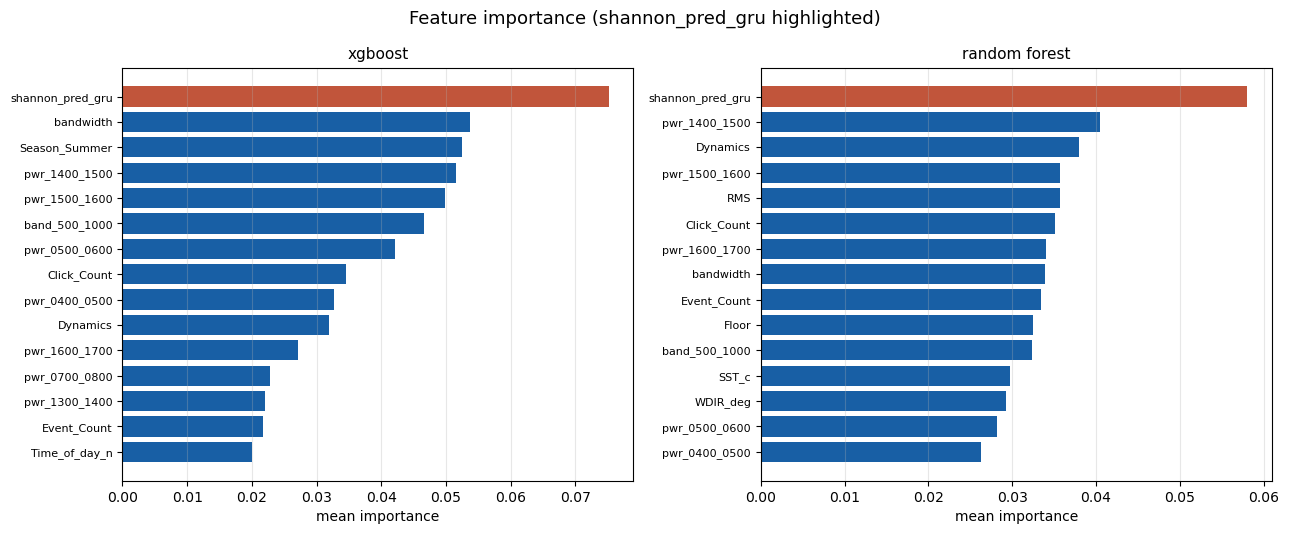

xgboost        shannon_pred_gru ranks 1 of 45 (importance 0.0752)
random forest  shannon_pred_gru ranks 1 of 45 (importance 0.0580)


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, model in zip(axes, ["xgboost", "random forest"]):
    imp = pd.concat(importance[(model, "environment + acoustic + GRU")], axis=1).mean(axis=1)
    top = imp.sort_values(ascending=False).head(15)[::-1]
    cols = ["#C1553B" if i == PRED_COL else "#185FA5" for i in top.index]
    ax.barh(range(len(top)), top.values, color=cols)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(model, fontsize=11); ax.set_xlabel("mean importance")
    ax.grid(axis="x", alpha=0.3)
fig.suptitle(f"Feature importance ({PRED_COL} highlighted)", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

for model in ["xgboost", "random forest"]:
    imp = pd.concat(importance[(model, "environment + acoustic + GRU")], axis=1).mean(axis=1)
    rank = int((imp.sort_values(ascending=False).index == PRED_COL).argmax()) + 1
    print(f"{model:14s} {PRED_COL} ranks {rank} of {len(imp)} "
          f"(importance {imp[PRED_COL]:.4f})")

In [9]:

print(f"figures: {os.path.relpath(FIG_DIR, BASE)}/")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")

figures: figures/trees/
  boxplot_feature_sets.png
  feature_importance.png
